<a href="https://colab.research.google.com/github/xwang335/Campbell-A/blob/main/backtest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

print('Setup complete.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Setup complete.


In [13]:
import os

path = "/content/drive/MyDrive/Campbell A data/"

os.chdir(path)

In [14]:
# %% [markdown]
# ## Features Analysis
# * should be longer than 10 years

# %% [markdown]
# * sharpe ratio (annualize, volatility issue, should ~ 0.5/above 1) /correlating pnl (should be low correlation)/ correlation matrix across different strategies
# * test on over 10 years
# * correct features before moving on

# %%
import argparse
from curses import panel
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
# from rawdata_obtain import FEATURE_REGISTRY

# %%
def norm_rank(data):
    ranks=data.rank(method='average',na_option='keep')
    n=ranks.count()
    mapped = (ranks / (n + 1)) * 2 - 1
    return mapped.fillna(0)

def assign_decile(x):
    if len(x) < 10: # enough data points to assign deciles
        return pd.Series(index=x.index, data=np.nan)
    ranks = x.rank(method='first', ascending=True)
    return pd.qcut(ranks, 10, labels=False) + 1

def cumulate_return(df, date_col, rank_col, ret_col, weighting="equal"):
    df['decile'] = (
    df.groupby(date_col)[rank_col] # factors
    .transform(assign_decile)
    )
    if weighting == "equal":
        raw_port_ret = df.groupby([date_col, 'decile'])[ret_col].mean()

    if weighting == "value":
        df = df.sort_values(['permno', date_col])
        df['me_lag'] = df.groupby('permno')['me'].shift(1)
        # print(df[['date','permno','me','me_lag']].head(20))
        df = df.dropna(subset=['me_lag'])

        raw_port_ret = (
        df.groupby([date_col, 'decile'])
        .apply(lambda x: np.sum(x[ret_col] * x['me_lag']) / np.sum(x['me_lag']), include_groups=False)
        )

    port_ret = raw_port_ret.unstack('decile')
    port_ret['LS'] = port_ret[10] - port_ret[1]
    #port_ret['LS_cumret'] = (1 + port_ret['LS']).cumprod() - 1
    port_ret['LS_ariret'] = port_ret['LS'].cumsum()

    return port_ret.reset_index()

def ret_plot(port_ret, model_name, weighting):
    plt.plot(port_ret['date'], port_ret['LS_ariret'])
    plt.title(f"{weighting.capitalize()}-Weighted Long-Short based on {model_name}")
    plt.xlabel("Date")
    plt.ylabel("Arithmetic Return")
    plt.grid(True)
    ax = plt.gca()
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)) # 1.0 as 100%
    plt.savefig(f"Outputs/{model_name}_{weighting}_ret.png")
    #plt.show()
    print(f"--- Return Plot Saved to Outputs/{model_name}_{weighting}_ret.png ---")

def ret_summary(port_ret):
    ls_ret = port_ret['LS'].dropna()

    T = len(ls_ret)
    mean_monthly = ls_ret.mean()
    std_monthly = ls_ret.std()

    t_stat = mean_monthly / (std_monthly / np.sqrt(T))
    sharpe = (mean_monthly / std_monthly) * np.sqrt(12)

    return sharpe

def predictiveR2(df, feature_name, date_col, split_date):

    df = df.dropna(subset=[feature_name, 'exret'])

    df_train = df[df[date_col] < split_date]
    df_test = df[df[date_col] >= split_date]

    # perform OLS regression on the training set
    X_train = df_train[feature_name]
    X_train = np.column_stack([np.ones(X_train.shape[0]), X_train])  # add intercept
    # check

    y = df_train['exret'] # use excess return for R-squared calculation to align with author
    beta = np.linalg.lstsq(X_train, y, rcond=None)[0]
    # predict on the test set
    X_test = df_test[feature_name]
    X_test = np.column_stack([np.ones(X_test.shape[0]), X_test])  # add intercept
    y_test = df_test['exret']
    y_pred = X_test @ beta
    # calculate R-squared
    ss_res = (y_test - y_pred).T @ (y_test - y_pred)
    ss_tot = y_test.T @ y_test # do not demean y_test to align with author
    r2 = 1 - (ss_res / ss_tot) if ss_tot != 0 else 0

    return r2

def oos_r2(y_true, y_pred):
    """
    Out-of-sample R² with zero benchmark — Equation (19):
        R²_oos = 1 - Σ(r - r̂)² / Σr²
    """
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return 1.0 - np.sum((y_true - y_pred) ** 2) / np.sum(y_true ** 2)

def decile_table(df, date_col, rank_col, ret_col, weighting="equal"):

    df = df.copy()

    # ── decile 分组 ───────────────────────────────────────────────────────────
    def assign_decile_qcut(x):
        if len(x) < 10:
            return pd.Series(np.nan, index=x.index)
        return pd.qcut(x[rank_col].rank(method='first'), 10, labels=False) + 1

    df['decile'] = df.groupby(date_col, group_keys=False).apply(assign_decile_qcut)
    df = df.dropna(subset=['decile'])
    df['decile'] = df['decile'].astype(int)


    if weighting == "value":
        df = df.sort_values(['permno', date_col])
        df['me_lag'] = df.groupby('permno')['me'].shift(1)
        df = df.dropna(subset=['me_lag'])
        monthly = (
            df.groupby([date_col, 'decile'])
            .apply(lambda g: pd.Series({
                'ret_w' : np.sum(g[ret_col]  * g['me_lag']) / np.sum(g['me_lag']),
                'pred_w': np.sum(g[rank_col] * g['me_lag']) / np.sum(g['me_lag']),
            }), include_groups=False)
            .reset_index()
        )
    else:
        monthly = (
            df.groupby([date_col, 'decile'])
            .agg(ret_w=(ret_col, 'mean'), pred_w=(rank_col, 'mean'))
            .reset_index()
        )

    def ann_stats(group):
        avg = group['ret_w'].mean() * 12
        vol = group['ret_w'].std() * np.sqrt(12)
        sr  = avg / vol if vol != 0 else np.nan
        pred = group['pred_w'].mean()
        return pd.Series({
            'Pred'         : pred,
            'Realized (%)'  : avg * 100,
            'Vol (%)'       : vol * 100,
            'Sharpe'        : sr,
        })

    tbl = monthly.groupby('decile').apply(ann_stats).reset_index()

    pivot = monthly.pivot(index=date_col, columns='decile', values='ret_w')
    hl = pivot[10] - pivot[1]
    hl_avg = hl.mean() * 12
    hl_vol = hl.std() * np.sqrt(12)
    hl_sr  = hl_avg / hl_vol if hl_vol != 0 else np.nan

    pred_10 = tbl.loc[tbl['decile'] == 10, 'Pred'].values[0]
    pred_1  = tbl.loc[tbl['decile'] == 1,  'Pred'].values[0]

    hl_row = pd.DataFrame([{
        'decile'       : 'H-L',
        'Pred'         : pred_10 - pred_1,
        'Realized (%)'  : hl_avg * 100,
        'Vol (%)'       : hl_vol * 100,
        'Sharpe'        : hl_sr,
    }])

    tbl = pd.concat([tbl, hl_row], ignore_index=True)
    return tbl

def run_trade_pipeline(file_name, weighting):

    # call the function to trade the features
    temp1 = pd.read_parquet("crsp_monthly.parquet")
    temp2 = pd.read_parquet(f"{file_name}.parquet")

    temp1['date_m'] = pd.to_datetime(temp1['date']).dt.to_period('M')
    temp2['date_m'] = pd.to_datetime(temp2['DATE']).dt.to_period('M')

    panel = temp1.merge(temp2, on=['permno', 'date_m'], how='inner', suffixes=('', '_feat'))
    # print(panel['exret'])  # Debugging line to check data before cleaning

    port_ret = cumulate_return(df=panel, date_col='date', rank_col='y_pred', ret_col='ret', weighting=weighting)
    port_exret = cumulate_return(df=panel, date_col='date', rank_col='y_pred', ret_col='y_true', weighting=weighting)

    ret_plot(port_ret, file_name, weighting)

    tbl = decile_table(df=panel, date_col='date', rank_col='y_pred', ret_col='y_true', weighting=weighting)
    print(f"\n=== Decile Table ({weighting.capitalize()}-Weighted) ===")
    print(tbl.round(4).to_string(index=False))
    tbl_path = f"Outputs/{file_name}_{weighting}_decile.csv"
    tbl.to_csv(tbl_path, index=False)
    print(f"--- Decile Table Saved to {tbl_path} ---")

    IR = ret_summary(port_ret)
    sharpe = ret_summary(port_exret)
    r2 = oos_r2(panel['y_true'], panel['y_pred'])

    output_text = (
        f"Annualized Sharpe Ratio: {sharpe:.2f}\n"
        f"Information Ratio: {IR:.2f}\n"
        f"Predictive R-squared: {r2:.5f}\n"
    )
    file_path = f"Outputs/{file_name}_{weighting}_summary.txt"
    with open(file_path, "w") as f:
        f.write(output_text)

    print(f"--- Summary Results Saved to {file_path} ---")
    print(output_text)

# %%
#if __name__ == "__main__":
#   run_trade_pipeline()


--- Return Plot Saved to Outputs/glm_predictions_value_ret.png ---

=== Decile Table (Value-Weighted) ===
decile    Pred  Realized (%)  Vol (%)  Sharpe
     1 -0.0037        2.0601  24.2801  0.0848
     2  0.0002        6.8567  17.3488  0.3952
     3  0.0022        6.1935  16.2993  0.3800
     4  0.0037        7.5383  15.3057  0.4925
     5  0.0050        8.2545  15.4118  0.5356
     6  0.0064        8.3855  15.1091  0.5550
     7  0.0079        8.8920  14.9129  0.5963
     8  0.0096        8.8434  15.8754  0.5570
     9  0.0118        9.6755  16.4622  0.5877
    10  0.0153       13.7605  18.5005  0.7438
   H-L     NaN       11.7004  18.8557  0.6205
--- Decile Table Saved to Outputs/glm_predictions_value_decile.csv ---
--- Summary Results Saved to Outputs/glm_predictions_value_summary.txt ---
Annualized Sharpe Ratio: 0.62
Information Ratio: 0.74
Predictive R-squared: 0.00179



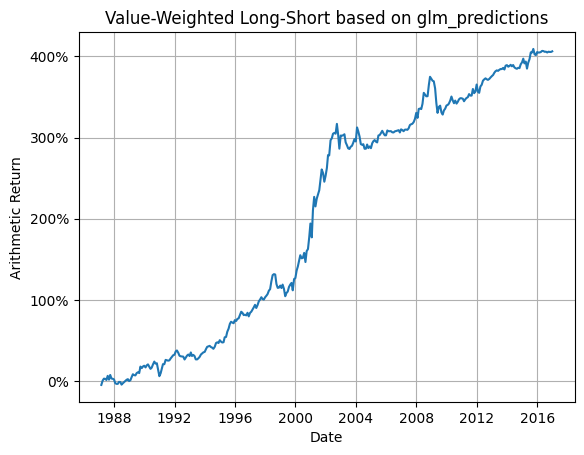

In [15]:
run_trade_pipeline(file_name='glm_predictions', weighting='value')